# Iris Flower Classification

<img src="https://storage.googleapis.com/kaggle-media/learn/images/RcxYYBA.png">


Набор данных о цветках ириса состоит из трёх видов: setosa, versicolor и virginica. Эти виды можно различить по их размерам. У вас есть датасет https://raw.githubusercontent.com/nngasu4course/Credit_Score/refs/heads/main/iris.csv , в котором размеры цветков ириса соотнесены с видом цветка.



In [1]:
# Importing Dependencies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:

url="https://raw.githubusercontent.com/nngasu4course/Credit_Score/refs/heads/main/iris.csv"

iris=pd.read_csv(url)

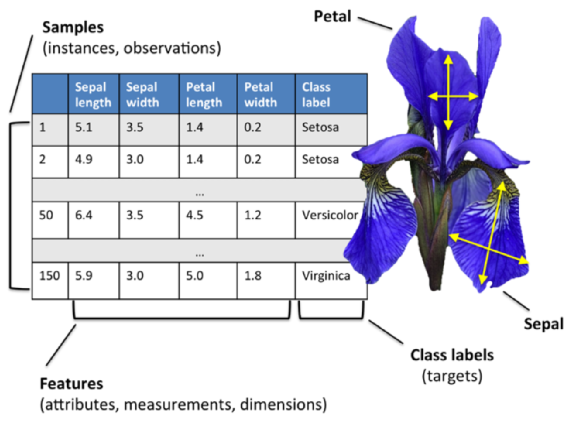

In [3]:
iris

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


# **Разведочный анализ данных ( Exploratory Data Analysis, EDA )**

In [4]:
iris.shape

(150, 5)

In [5]:
iris.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [6]:
iris.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [7]:
iris.isnull().sum()

,0
sepal_length,0
sepal_width,0
petal_length,0
petal_width,0
species,0


In [8]:
data = iris.drop_duplicates(subset ="species",)
data

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
50,7.0,3.2,4.7,1.4,versicolor
100,6.3,3.3,6.0,2.5,virginica


In [9]:
iris.value_counts("species")

,count
species,
setosa,50
versicolor,50
virginica,50


In [10]:
iris.groupby('species').mean()

,sepal_length,sepal_width,petal_length,petal_width
species,,,,
setosa,5.006,3.418,1.464,0.244
versicolor,5.936,2.770,4.260,1.326
virginica,6.588,2.974,5.552,2.026


# **## Data Visualization**

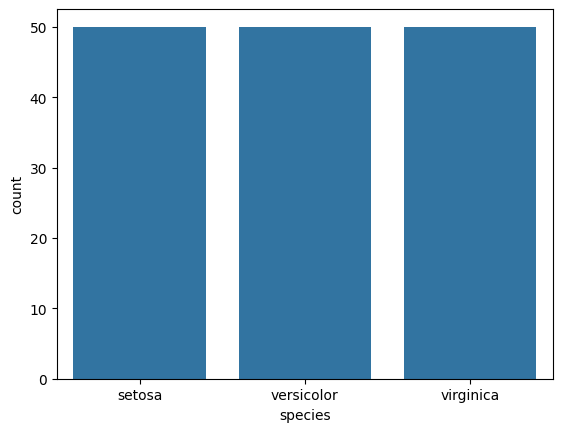

In [11]:
# importing packages
import seaborn as sns
import matplotlib.pyplot as plt


sns.countplot(x='species', data=iris, )
plt.show()

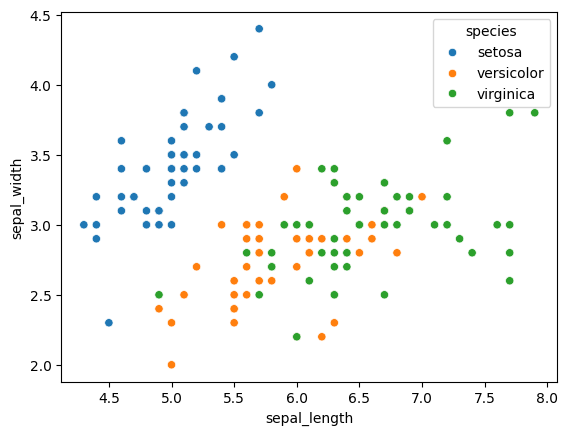

In [12]:
sns.scatterplot(x='sepal_length', y='sepal_width', hue='species', data=iris)
plt.show()

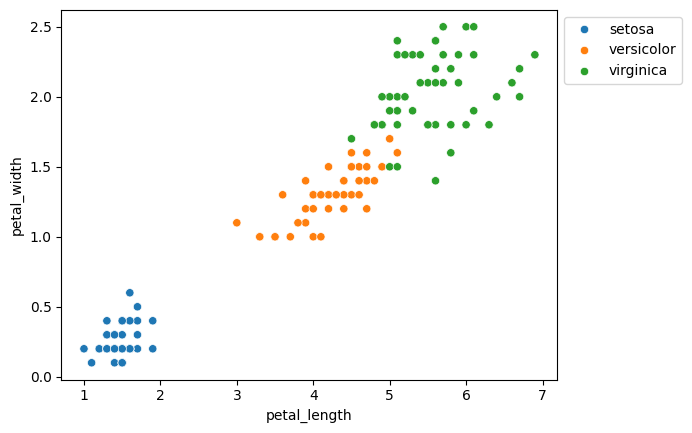

In [13]:
# importing packages
import seaborn as sns
import matplotlib.pyplot as plt


sns.scatterplot(x='petal_length', y='petal_width',
                hue='species', data=iris, )

# Placing Legend outside the Figure
plt.legend(bbox_to_anchor=(1, 1), loc=2)

plt.show()

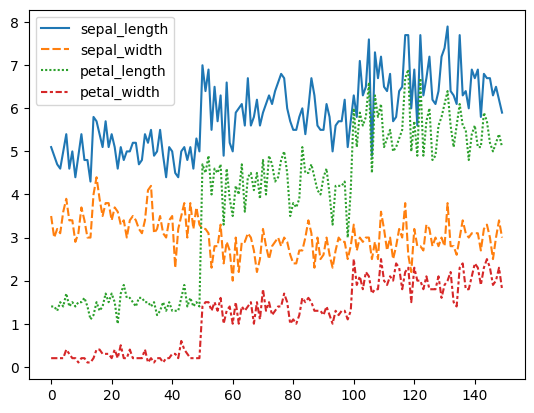

In [14]:
sns.lineplot(data=iris.drop(['species'], axis=1))
plt.show()

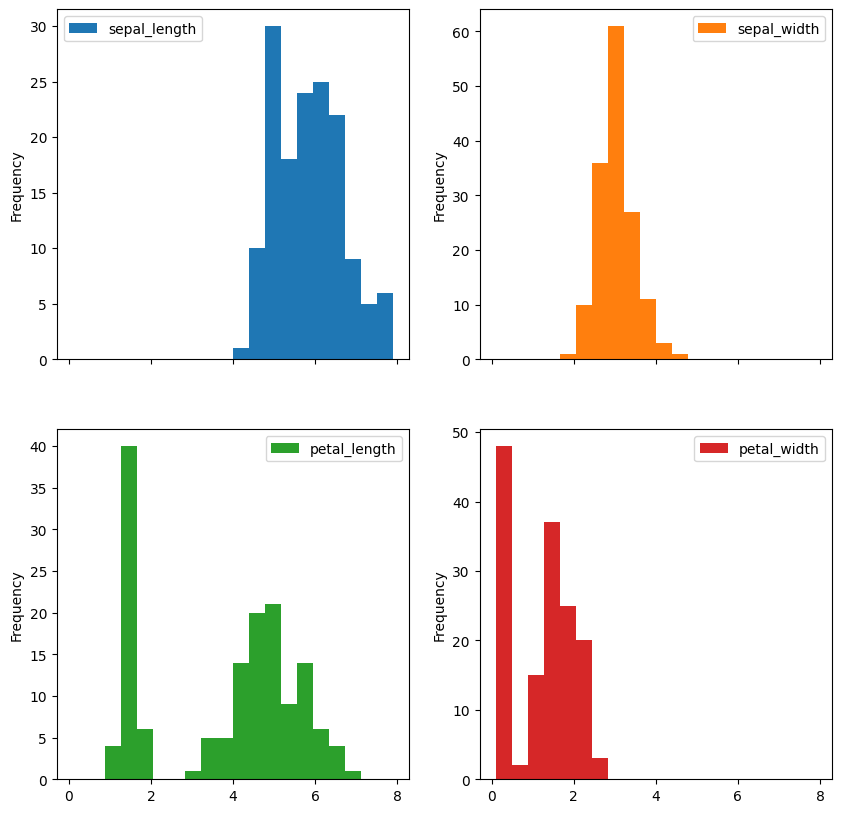

In [15]:
iris.plot.hist(subplots=True, layout=(2,2), figsize=(10, 10), bins=20)
plt.show()

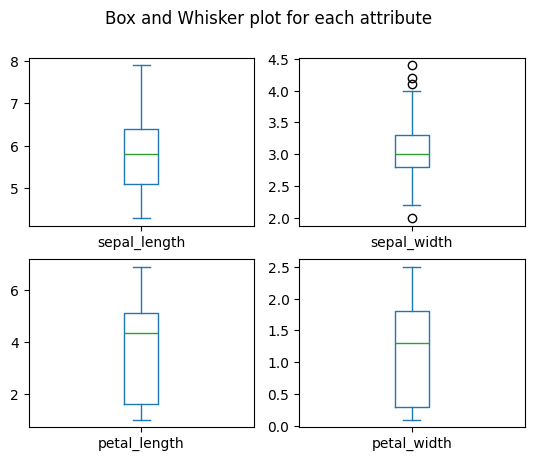

In [16]:
# box and whisker plots
iris.plot(kind='box', subplots=True, layout=(2,2),
               sharex=False, sharey=False, title="Box and Whisker plot for each attribute")
plt.show()

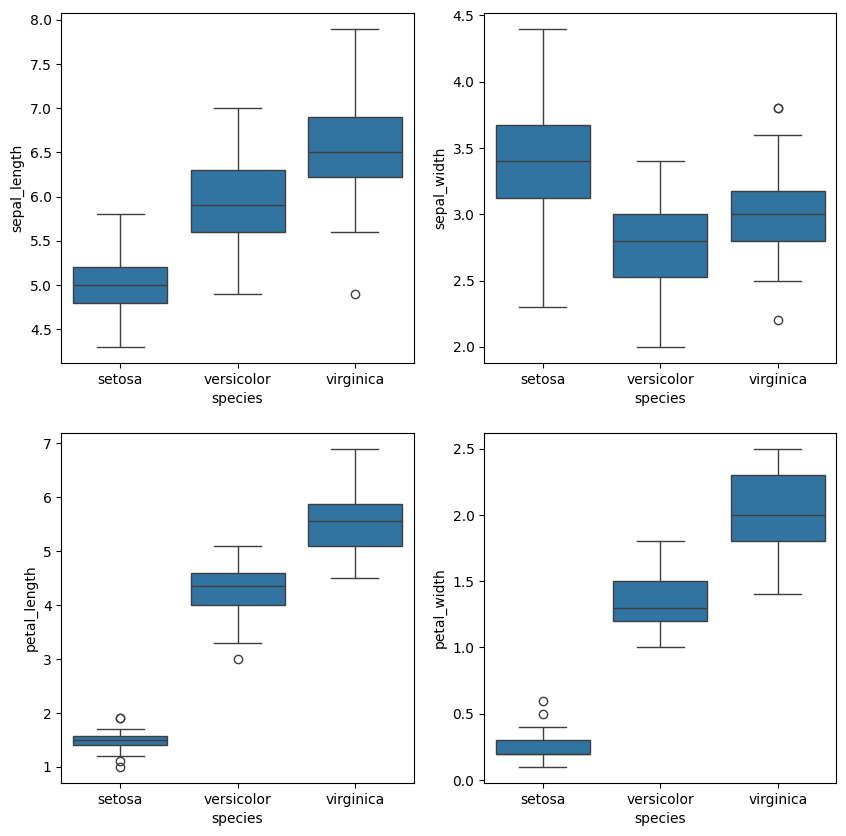

In [17]:

def graph(y):
    sns.boxplot(x="species", y=y, data=iris)

plt.figure(figsize=(10,10))

# Adding the subplot at the specified
# grid position
plt.subplot(221)
graph('sepal_length')

plt.subplot(222)
graph('sepal_width')

plt.subplot(223)
graph('petal_length')

plt.subplot(224)
graph('petal_width')

plt.show()

<Axes: xlabel='sepal_width'>

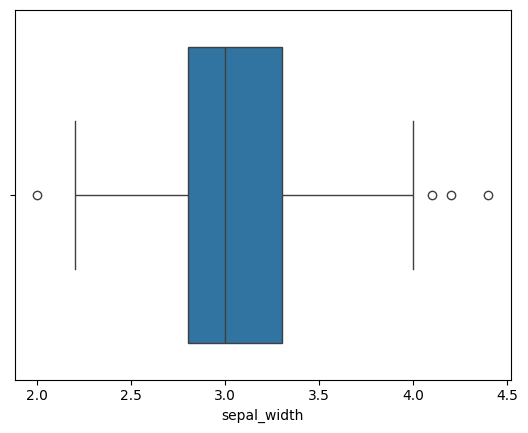

In [18]:
sns.boxplot(x='sepal_width', data=iris)

# По boxplot видим выбросы. Устраняем

Old Shape:  (150, 5)
New Shape:  (146, 5)


<Axes: xlabel='sepal_width'>

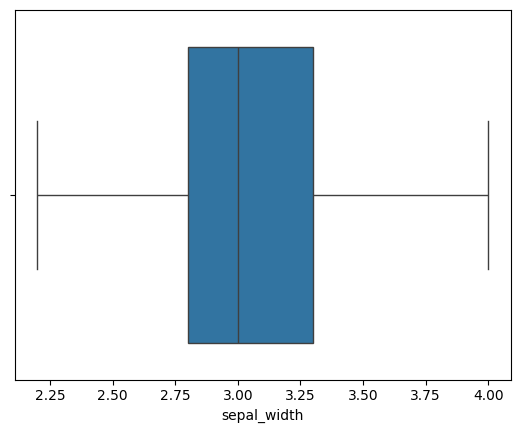

In [19]:

# IQR
Q1 = np.percentile(iris['sepal_width'], 25,
				interpolation = 'midpoint')

Q3 = np.percentile(iris['sepal_width'], 75,
				interpolation = 'midpoint')
IQR = Q3 - Q1

print("Old Shape: ", iris.shape)

# Upper bound
upper = np.where(iris['sepal_width'] >= (Q3+1.5*IQR))

# Lower bound
lower = np.where(iris['sepal_width'] <= (Q1-1.5*IQR))

# Removing the Outliers
iris.drop(upper[0], inplace = True)
iris.drop(lower[0], inplace = True)

print("New Shape: ", iris.shape)

sns.boxplot(x='sepal_width', data=iris)



# ML не умеет работать с текстом. Заменяем

In [20]:
d = {"setosa":0, "versicolor":1, "virginica":2}
iris['species'] = iris['species'].map(d)



In [21]:
iris

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


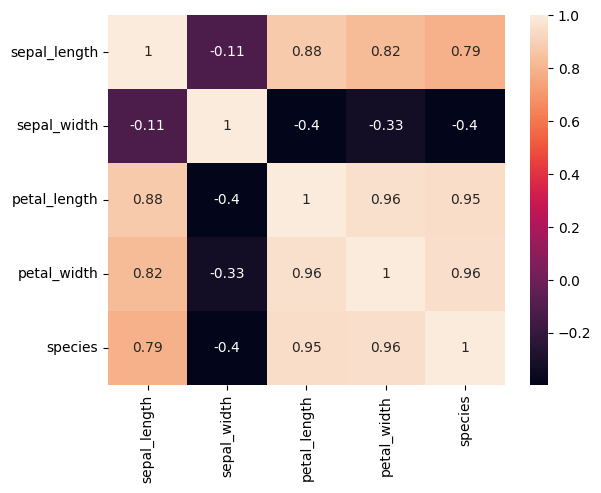

In [22]:
sns.heatmap(iris.corr(), annot=True)
plt.show()




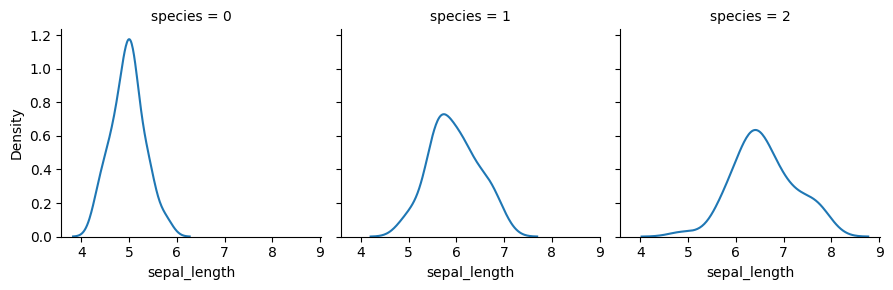

In [23]:
g = sns.FacetGrid(iris, col='species')
g = g.map(sns.kdeplot, 'sepal_length')

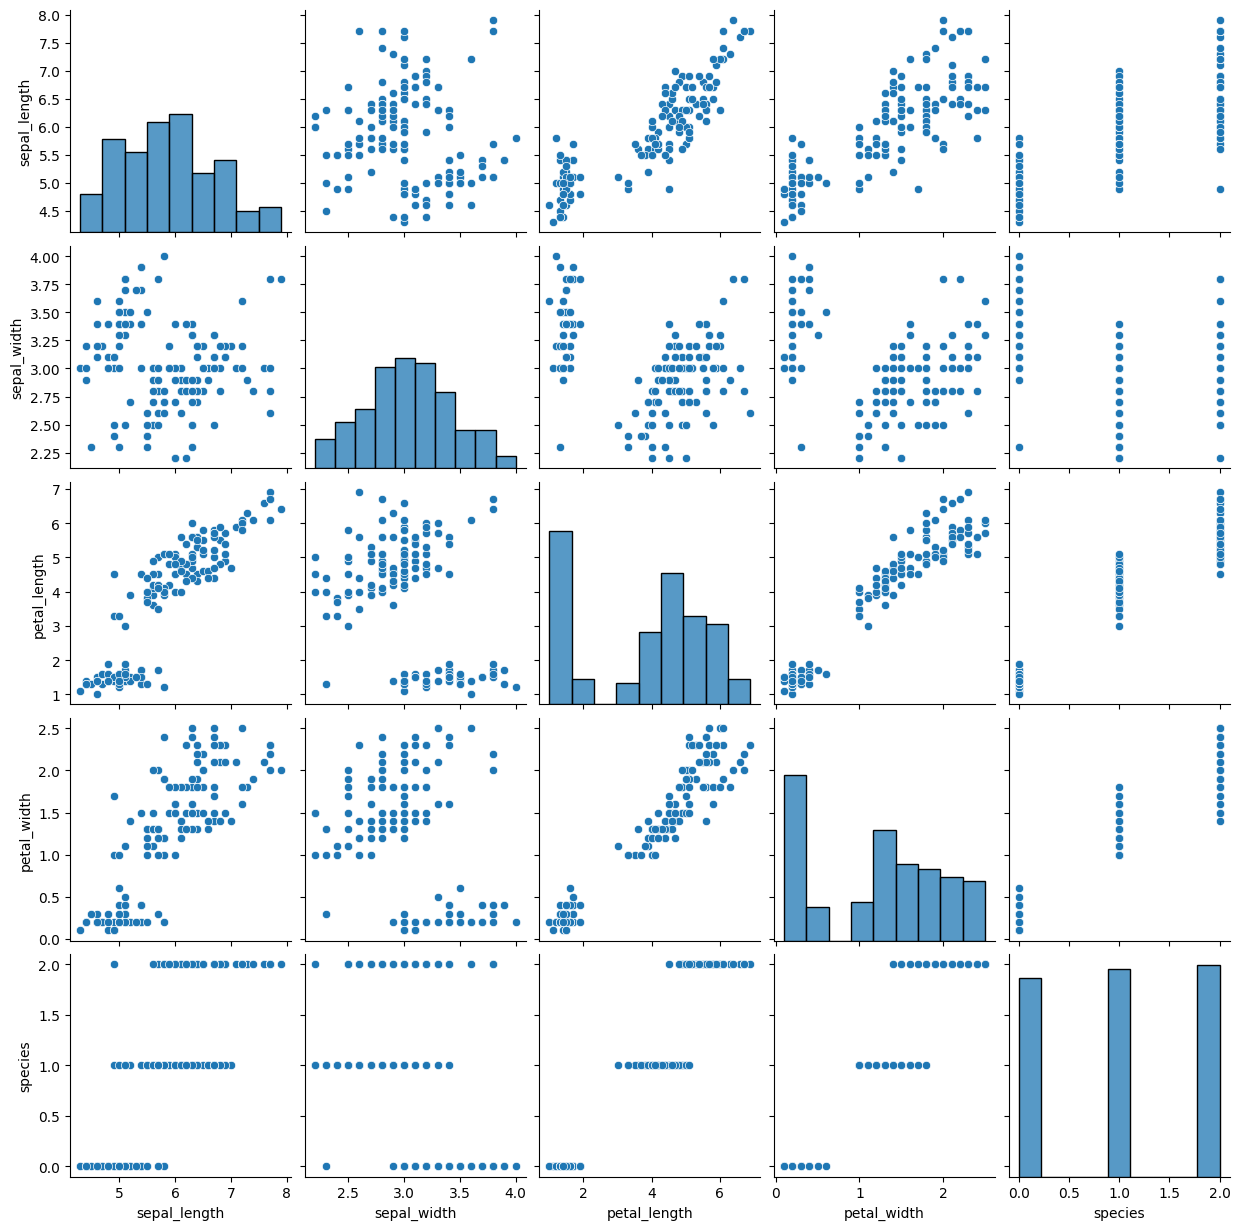

In [24]:
sns.pairplot(iris)

### **Machine Learning**

In [25]:
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.metrics import accuracy_score

In [26]:
x = iris.drop('species', axis=1)
y= iris.species

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.4, random_state=5)

### <font color="blue"><b>K Neighbors Classifier</b></font>

К-ближайших соседей (K-Nearest Neighbors или просто KNN) — алгоритм классификации и регрессии, основанный на гипотезе компактности, которая предполагает, что расположенные близко друг к другу объекты в пространстве признаков имеют схожие значения целевой переменной или принадлежат к одному классу.
Принцип работы KNN

Алгоритм строится следующим образом:


1.   Выберите значение K: Количество соседей (K), которые следует учитывать, является критическим гиперпараметром. Выбор K может существенно повлиять на производительность модели.
2.   Вычисление расстояний: Для новой точки данных алгоритм вычисляет расстояние между ней и каждой другой точкой в обучающем наборе данных.
3.   Определение соседей: Он определяет K точек данных из обучающего набора, которые находятся ближе всего к новой точке. Это «ближайшие соседи».



    

In [27]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5, p=2, metric='minkowski')
knn.fit(x_train, y_train)

knn.score(x_test, y_test)

0.9661016949152542

In [28]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, f1_score, recall_score, classification_report
y_pred=knn.predict(x_test)

print(classification_report(y_test, y_pred));


              precision    recall  f1-score   support

           0       1.00      1.00      1.00        18
           1       0.96      0.96      0.96        23
           2       0.94      0.94      0.94        18

    accuracy                           0.97        59
   macro avg       0.97      0.97      0.97        59
weighted avg       0.97      0.97      0.97        59



### <font color="blue"><b>Logistic Regression</b></font>


Логистическая регрессия — это алгоритм машинного обучения, который используется для решения задачи бинарной классификации, то есть разделения данных на два класса. Она получила свое название благодаря тому, что использует логистическую функцию для прогнозирования вероятности принадлежности объекта к одному из классов.

In [29]:
from sklearn.linear_model import LogisticRegression
logreg = LogisticRegression()
logreg.fit(x, y)
y_pred = logreg.predict(x)
print(metrics.accuracy_score(y, y_pred))

0.9726027397260274


In [30]:

y_pred=logreg.predict(x_test)

print(classification_report(y_test, y_pred));

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        18
           1       0.95      0.91      0.93        23
           2       0.89      0.94      0.92        18

    accuracy                           0.95        59
   macro avg       0.95      0.95      0.95        59
weighted avg       0.95      0.95      0.95        59



### <font color="blue"><b>SVM</b></font>

Основная идея метода заключается в построении гиперплоскости, разделяющей объекты выборки оптимальным способом. Алгоритм работает в предположении, что чем больше расстояние (зазор) между разделяющей гиперплоскостью и объектами разделяемых классов, тем меньше будет средняя ошибка классификатора.

In [31]:
from sklearn.svm import SVC
svm = SVC(kernel='rbf', random_state=0, gamma=.10, C=1.0)
svm.fit(x_train, y_train)

svm.score(x_test, y_test)

0.9491525423728814

In [32]:
y_pred=svm.predict(x_test)

print(classification_report(y_test, y_pred));

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        18
           1       0.95      0.91      0.93        23
           2       0.89      0.94      0.92        18

    accuracy                           0.95        59
   macro avg       0.95      0.95      0.95        59
weighted avg       0.95      0.95      0.95        59



### <font color="blue"><b>Decision Tree Classifier</b></font>

Дерево решений — классификатор, построенный на основе решающих правил вида «если, то».  Логические условия объединяются в структуру дерева.

In [33]:
from sklearn.tree import DecisionTreeClassifier
dtree = DecisionTreeClassifier()
dtree.fit(x_train, y_train)

dtree.score(x_test, y_test)

0.9491525423728814

In [34]:
from sklearn.model_selection import train_test_split

X=iris[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']]  # Features
y=iris['species']  # Labels

# Split dataset into training set and test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3) # 70% training and 30% test

### <font color="blue"><b>Bagging</b></font>

Бэггинг.
Бэггинг (англ. bootstrap aggregating) — это
ансамблевый метод машинного обучения, который улучшает точность и стабильность моделей путём обучения нескольких алгоритмов на разных подвыборках данных, полученных случайной выборкой с заменой. Этот метод помогает снизить дисперсию и уменьшить переобучение

Преимущества


*   Уменьшение дисперсии: Усреднение предсказаний нескольких моделей снижает разброс (дисперсию) итогового прогноза.

*   Снижение переобучения: Бэггинг делает модель более устойчивой к шуму в данных.
*   Увеличение точности: Точность ансамбля, как правило, выше, чем у любой отдельной модели




### <font color="blue"><b>Random Forest Classifier</b></font>

Алгоритм случайного леса (Random Forest) — универсальный алгоритм машинного обучения, суть которого состоит в использовании ансамбля решающих деревьев. Само по себе решающее дерево предоставляет крайне невысокое качество классификации, но из-за большого их количества результат значительно улучшается. Также это один из немногих алгоритмов, который можно использовать в абсолютном большинстве задач. Метод случайного леса (Random Forest) представляет собой улучшение бэггинга деревьев решений, которое заключается в устранении корреляции между деревьями.

In [35]:
from sklearn.ensemble import RandomForestClassifier

#Create a Gaussian Classifier
clf=RandomForestClassifier(n_estimators=100)

#Train the model using the training sets y_pred=clf.predict(X_test)
clf.fit(X_train,y_train)

# prediction on test set
y_pred=clf.predict(X_test)

#Import scikit-learn metrics module for accuracy calculation
from sklearn import metrics
# Model Accuracy, how often is the classifier correct?
print("Accuracy:",metrics.accuracy_score(y_test, y_pred))

Accuracy: 0.9090909090909091


In [36]:
#d = {0: "setosa",1:"versicolor", 2:"virginica"}

species_idx = clf.predict([[3, 5, 4, 2]])[0]
print (species_idx)
#iris.target_names[species_idx]

2


In [37]:
print(classification_report(y_test, y_pred));

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       0.81      1.00      0.89        17
           2       1.00      0.73      0.85        15

    accuracy                           0.91        44
   macro avg       0.94      0.91      0.91        44
weighted avg       0.93      0.91      0.91        44



In [38]:
confusion_matrix(y_test, y_pred)

array([[12,  0,  0],
       [ 0, 17,  0],
       [ 0,  4, 11]])

Axes(0.125,0.11;0.62x0.77)


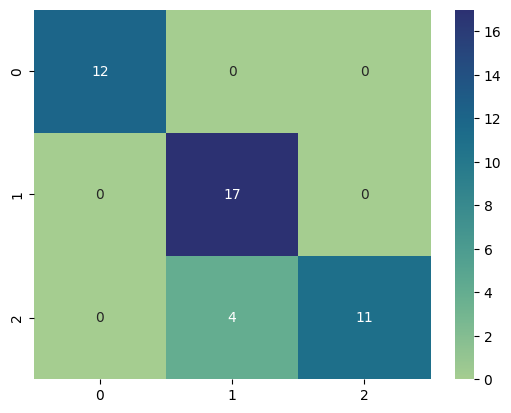

In [39]:
print(sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, cmap="crest", fmt='g'));

### <font color="blue"><b>Boosting</b></font>


Бустинг — это метод ансамблевого обучения, используемый в классификации для повышения эффективности прогнозирования путём объединения нескольких слабых обучающихся алгоритмов, обычно деревьев решений, для формирования сильного обучающегося алгоритма. В отличие от бэггинга, который строит модели независимо, бустинг строит модели последовательно, при этом каждая новая модель фокусируется на исправлении ошибок, допущенных предыдущими. Этот процесс присваивает больший вес неправильно классифицированным примерам, гарантируя, что последующие модели будут более эффективно устранять эти ошибки. К популярным алгоритмам бустинга относятся AdaBoost, Gradient Boosting и XGBoost. Благодаря итеративному уточнению модели, бустинг снижает смещение, что приводит к повышению точности задач классификации.


### <font color="blue"><b>Gradient Boosting Classifier</b></font>

Accuracy: 1.0
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



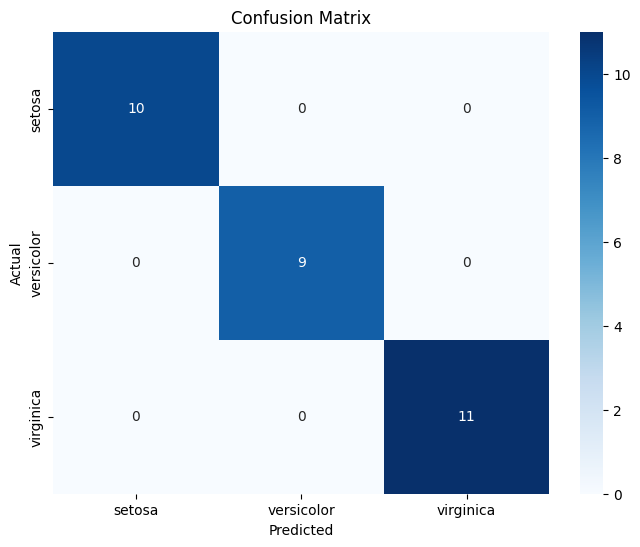

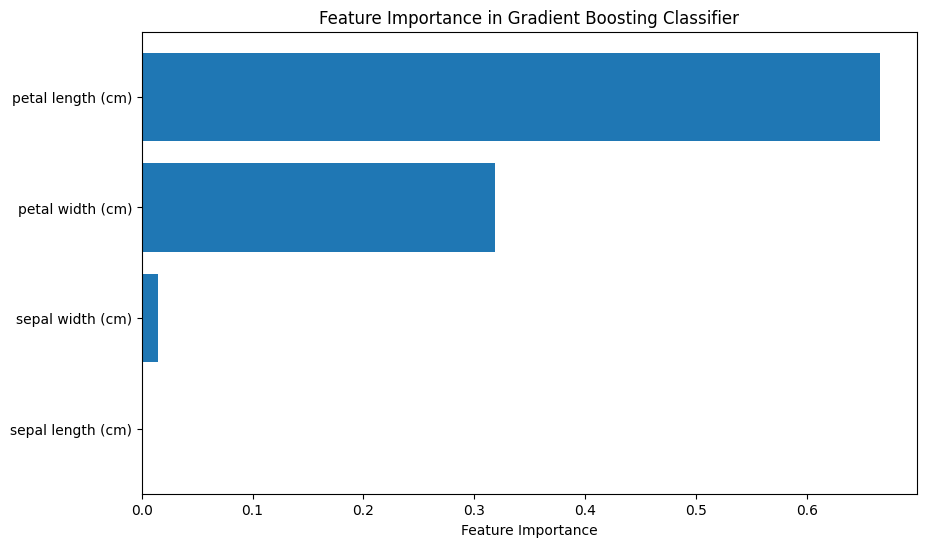

In [40]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.datasets import load_iris

# Load the Iris dataset
data = load_iris()
X = data.data
y = data.target

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the Gradient Boosting Classifier
model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

# Generate a classification report
print(classification_report(y_test, y_pred, target_names=data.target_names))

# Plot the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=data.target_names, yticklabels=data.target_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Plot feature importance
feature_importance = model.feature_importances_
sorted_idx = np.argsort(feature_importance)
plt.figure(figsize=(10, 6))
plt.barh(range(len(sorted_idx)), feature_importance[sorted_idx], align='center')
plt.yticks(range(len(sorted_idx)), np.array(data.feature_names)[sorted_idx])
plt.xlabel('Feature Importance')
plt.title('Feature Importance in Gradient Boosting Classifier')
plt.show()

### <font color="blue"><b> Hyperparameter Tuning</b></font>

Гиперпараметры — это
внешние настройки модели машинного обучения, задаваемые до начала обучения, которые не изменяются автоматически. <br>
Настройка гиперпараметров — это экспериментальная практика, при которой на каждой итерации проверяются различные значения гиперпараметров до тех пор, пока не будут определены наилучшие . Этот процесс критически важен для эффективности модели, поскольку гиперпараметры управляют процессом её обучения.

**Настройка гиперпараметров для SVM**


Параметр регуляризации (C): Определяет баланс между настройкой модели под обучающие данные и минимизацией ошибки на тестовых данных.<br>
gamma: параметр можно рассматривать как величину, обратную радиусу влияния выборок, выбранных моделью в качестве опорных векторов.<br>
kernel: Определяет функцию, используемую для преобразования данных для разделения классов. Например, линейную или rbf. Влияет на "гладкость" границы решения, контролируя радиус влияния одного образца



In [41]:
from sklearn.model_selection import KFold
from sklearn.model_selection import GridSearchCV
svm_param_grid = {'C':[0.001, 0.01, 0.1, 1, 10, 100, 1000],
                  'kernel': ['linear', 'rbf','poly'],
                  'gamma' :[0.0001, 0.001, 0.01, 0.1, 1, 10, 100]}
svm_cv = KFold(n_splits=5)
svm_grid = GridSearchCV(SVC(), svm_param_grid, cv=svm_cv, scoring='accuracy')
svm_grid.fit(X_train, y_train)

GridSearchCV(cv=KFold(n_splits=5, random_state=None, shuffle=False),
             estimator=SVC(),
             param_grid={'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000],
                         'gamma': [0.0001, 0.001, 0.01, 0.1, 1, 10, 100],
                         'kernel': ['linear', 'rbf', 'poly']},
             scoring='accuracy')

In [42]:
print('SVM best Params:', svm_grid.best_params_)
print('SVM best Score:', svm_grid.best_score_)

SVM best Params: {'C': 100, 'gamma': 0.01, 'kernel': 'rbf'}
SVM best Score: 0.9666666666666668


In [43]:
svm_y_pred = svm_grid.predict(X_test)
print('Accuracy Score:', accuracy_score(y_test, svm_y_pred))
print('Confusion Matrix:\n', confusion_matrix(y_test, svm_y_pred))
print('Classification Report:\n', classification_report(y_test, svm_y_pred))

Accuracy Score: 1.0
Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



**Настройка гиперпараметров Random Forest**

max_samples: параметр определяет количество выборок (строк), извлекаемых из набора данных при обучении каждого отдельного дерева решений. <br>

max_features: параметр управляет количеством признаков (или столбцов), которые каждое отдельное дерево решений учитывает при поиске наилучшего разделения в каждом узле.<br>

n_estimators: параметр определяет количество отдельных деревьев решений, которые будут построены и объединены для формирования случайного леса.<br>

max_depth: максимальная глубина деревьев. Глубина дерева решений определяется как самый длинный путь от корневого узла до любого листового узла. Каждое разбиение дерева увеличивает его глубину.


In [44]:
rf_param_grid = {'max_samples': [0.1, 0.2, 0.3, 0.4],
                'max_features': [1, 2],
                'n_estimators':[10, 50, 100],
                'max_depth': [8, 9, 10]
                }
rf_cv = KFold(n_splits=5)
rf_grid = GridSearchCV(RandomForestClassifier(), rf_param_grid, cv=rf_cv)
rf_grid.fit(X_train, y_train)

GridSearchCV(cv=KFold(n_splits=5, random_state=None, shuffle=False),
             estimator=RandomForestClassifier(),
             param_grid={'max_depth': [8, 9, 10], 'max_features': [1, 2],
                         'max_samples': [0.1, 0.2, 0.3, 0.4],
                         'n_estimators': [10, 50, 100]})

In [ ]:
print('RF best Parameters:', rf_grid.best_estimator_)
print('RF best Score:', rf_grid.best_score_)

RF best Parameters: RandomForestClassifier(max_depth=10, max_features=2, max_samples=0.3,
                       n_estimators=50)
RF best Score: 0.9583333333333334


In [45]:

rf_y_pred = rf_grid.predict(X_test)
print('Accuracy:', accuracy_score(y_test, rf_y_pred))
print('Confusion Matrix:\n', confusion_matrix(y_test, rf_y_pred))
print('Classification Report:\n', classification_report(y_test, rf_y_pred))

Accuracy: 1.0
Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

